# 04 Model Training: モデル比較と学習戦略の決定

**目的**: 候補モデルを比較し、最適なアーキテクチャ・学習戦略・ハイパーパラメータを決定する。

**決定すること**:
1. TimeSeriesSplit vs ランダム分割の選択根拠
2. モデル比較（ベースライン / Ridge / LightGBM）
3. LightGBM ハイパーパラメータ
4. Early stopping の設定
5. 4 ターゲットを個別モデルで学習する設計

## Setup

In [14]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import ERROR_UNITS, load_base_dataset, get_feat_cols, metrics, build_features, RANDOM_STATE  # noqa: E402

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.float_format", "{:.4f}".format)

## データ準備（`03_feature_engineering.ipynb` の実装を再利用）

In [15]:
base_df  = load_base_dataset()
features = build_features(base_df, is_inference=False)
print(f"features: {features.shape}")

features: (26304, 219)


In [16]:
TARGET_COLS = ERROR_UNITS  # {target: unit} — utils.ERROR_UNITS のエイリアス

## 分割戦略

時系列データのため、未来データが train に混入しない **TimeSeriesSplit (n_splits=5)** を使用する。

In [17]:
QUICK_PARAMS = dict(
    objective="regression", metric="mae", n_estimators=200,
    learning_rate=0.1, num_leaves=31, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
)

tscv_rows = []
for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    feat_cols = get_feat_cols(df_t)
    X, y = df_t[feat_cols].fillna(0), df_t[target]

    fold_maes = []
    for tr, val in TimeSeriesSplit(n_splits=5).split(X):
        m = lgb.LGBMRegressor(**QUICK_PARAMS)
        m.fit(X.iloc[tr], y.iloc[tr])
        fold_maes.append(mean_absolute_error(y.iloc[val], m.predict(X.iloc[val])))

    tscv_rows.append({
        "target": target,
        "unit": unit,
        "MAE mean": np.mean(fold_maes),
        "MAE std":  np.std(fold_maes),
    })

display(pd.DataFrame(tscv_rows).set_index("target").round(4))

,unit,MAE mean,MAE std
target,,,
temp_error,℃,0.3825,0.0390
precip_error,mm,0.0863,0.0172
cloud_error,%,6.4709,0.9641
cloud_low_error,%,10.3862,0.6405


## LightGBM ハイパーパラメータ探索

Optuna の TPE サンプラーを使い、全ターゲット共通パラメータを一括最適化する。

**目的関数**: 全ターゲットの正規化 MAE（MAE / baseline_MAE）の平均 → 最小化
- スケール差（℃ / mm / %）を正規化することで、ターゲット間の寄与を均等に扱う

**探索パラメータ**: `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`（7 パラメータ）

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS           = 50
N_CV_SPLITS_SEARCH = 3  # 探索では fold 数を 5→3 に減らして高速化


def _combined_objective(trial: optuna.Trial) -> float:
    """全ターゲットの正規化 MAE 平均を最小化する。共通パラメータセットを 1 回で最適化できる。"""
    params = {
        "objective":         "regression",
        "metric":            "mae",
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate",     0.01, 0.10, log=True),
        "num_leaves":        trial.suggest_int  ("num_leaves",        15,   127),
        "min_child_samples": trial.suggest_int  ("min_child_samples", 10,   50),
        "subsample":         trial.suggest_float("subsample",         0.6,  1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree",  0.6,  1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",         1e-3, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",        1e-3, 1.0, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }

    normalized_scores = []
    for target in TARGET_COLS:
        df_t     = features.dropna(subset=[target]).copy()
        X_t      = df_t[get_feat_cols(df_t)].fillna(0)
        y_t      = df_t[target]
        baseline = float(y_t.abs().mean())

        fold_maes = []
        for tr_idx, val_idx in TimeSeriesSplit(n_splits=N_CV_SPLITS_SEARCH).split(X_t):
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_t.iloc[tr_idx], y_t.iloc[tr_idx],
                eval_set=[(X_t.iloc[val_idx], y_t.iloc[val_idx])],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            fold_maes.append(mean_absolute_error(y_t.iloc[val_idx], m.predict(X_t.iloc[val_idx])))

        normalized_scores.append(np.mean(fold_maes) / baseline)

    return float(np.mean(normalized_scores))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(_combined_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial: #{study.best_trial.number}  value={study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: #42  value=0.420684
Best params:
  learning_rate            : 0.0211752636910982
  num_leaves               : 51
  min_child_samples        : 15
  subsample                : 0.6666521290548713
  colsample_bytree         : 0.9704560740059139
  reg_alpha                : 0.37854170131413656
  reg_lambda               : 0.003822554326966834


Parameter importances:
  min_child_samples        : 0.8724
  colsample_bytree         : 0.0466
  learning_rate            : 0.0447
  subsample                : 0.0110
  reg_alpha                : 0.0092
  num_leaves               : 0.0087
  reg_lambda               : 0.0074


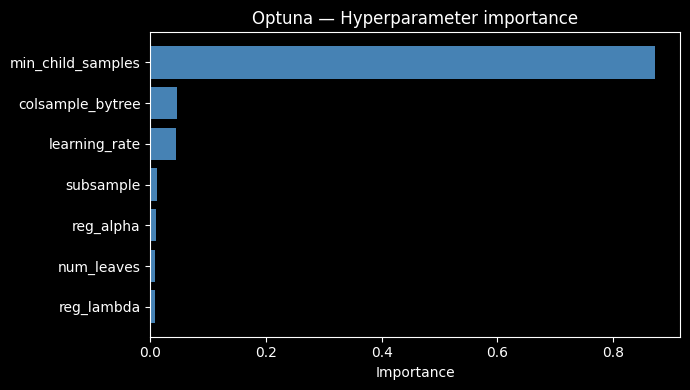

In [19]:
# パラメータ重要度（どのパラメータが最もスコアに影響したか）
importances = optuna.importance.get_param_importances(study)
print("Parameter importances:")
for k, v in importances.items():
    print(f"  {k:25s}: {v:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(importances.keys()), list(importances.values()), color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Optuna — Hyperparameter importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# 共通パラメータにする理由:
#   Optuna の目的関数が全ターゲットの正規化 MAE 平均を最小化しており、
#   1 セットのパラメータが全ターゲットに対して総合的に最良となる設計。
#   実装・運用の統一を重視し、per-target チューニングは行わない。
#
# subsample_freq=1:
#   LightGBM のデフォルト(0)では subsample の値にかかわらず Bagging が無効になる。
#   Optuna で subsample を探索するために明示的に 1 を設定する。
#   lag 特徴量により時系列構造は特徴量で表現されているため、行ランダムサンプリングの影響は限定的。

FINAL_LGBM_PARAMS = {
    "objective":      "regression",
    "metric":         "mae",
    "n_estimators":   1000,
    "subsample_freq": 1,          # subsample を有効にするために必要
    **study.best_params,          # Optuna が決定したパラメータ（上記セル参照）
    "random_state":   RANDOM_STATE,
    "n_jobs":         -1,
    "verbose":        -1,
}
EARLY_STOPPING = 50

print("Final LightGBM parameters (from Optuna):")
for k, v in FINAL_LGBM_PARAMS.items():
    print(f"  {k:25s}: {v}")
print(f"  {'early_stopping_rounds':25s}: {EARLY_STOPPING}")

Final LightGBM parameters (from Optuna):
  objective                : regression
  metric                   : mae
  n_estimators             : 1000
  subsample_freq           : 1
  learning_rate            : 0.0211752636910982
  num_leaves               : 51
  min_child_samples        : 15
  subsample                : 0.6666521290548713
  colsample_bytree         : 0.9704560740059139
  reg_alpha                : 0.37854170131413656
  reg_lambda               : 0.003822554326966834
  random_state             : 42
  n_jobs                   : -1
  verbose                  : -1
  early_stopping_rounds    : 50


In [21]:
import json, math

def _sigfig(x, n=3):
    """浮動小数点を有効数字 n 桁に丸める。Optuna の探索精度以上の桁数は意味がないため。"""
    if x == 0 or not isinstance(x, float):
        return x
    d = math.floor(math.log10(abs(x)))
    return round(x, -d + n - 1)

_deployment_dir = next(
    p for p in [Path("../deployment"), Path("deployment")]
    if p.is_dir()
)
_params_path = _deployment_dir / "lgbm_params.json"
_to_save = {
    k: _sigfig(v) if isinstance(v, float) else v
    for k, v in FINAL_LGBM_PARAMS.items()
    if k not in ("n_jobs", "verbose")
}
_params_path.write_text(json.dumps(_to_save, indent=2, ensure_ascii=False))
print(f"LGBM params saved → {_params_path}")
print(json.dumps(_to_save, indent=2))

LGBM params saved → ..\deployment\lgbm_params.json
{
  "objective": "regression",
  "metric": "mae",
  "n_estimators": 1000,
  "subsample_freq": 1,
  "learning_rate": 0.0212,
  "num_leaves": 51,
  "min_child_samples": 15,
  "subsample": 0.667,
  "colsample_bytree": 0.97,
  "reg_alpha": 0.379,
  "reg_lambda": 0.00382,
  "random_state": 42
}


## モデル比較: Baseline / Ridge / LightGBM

- **Baseline**: 予報そのまま（誤差 = 0 と予測）= 補正なし
- **Ridge**: 線形モデル（スケーリング必須）
- **LightGBM**: 勾配ブースティング

In [22]:
tscv = TimeSeriesSplit(n_splits=5)
model_rows = []

for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    feat_cols = get_feat_cols(df_t)
    X_t, y_t = df_t[feat_cols].fillna(0), df_t[target]

    bl, ridge_scores, lgbm_scores = [], [], []
    for tr, val in tscv.split(X_t):
        X_tr, X_val = X_t.iloc[tr], X_t.iloc[val]
        y_tr, y_val = y_t.iloc[tr], y_t.iloc[val]

        bl.append(mean_absolute_error(y_val, np.zeros(len(y_val))))

        pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
        pipe.fit(X_tr.fillna(0), y_tr)
        ridge_scores.append(mean_absolute_error(y_val, pipe.predict(X_val.fillna(0))))

        m = lgb.LGBMRegressor(**FINAL_LGBM_PARAMS)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False), lgb.log_evaluation(period=0)],
        )
        lgbm_scores.append(mean_absolute_error(y_val, m.predict(X_val)))

    model_rows.append({
        "target": target, "unit": unit,
        "Baseline": np.mean(bl),
        "Ridge":    np.mean(ridge_scores),
        "LightGBM": np.mean(lgbm_scores),
    })

model_df = pd.DataFrame(model_rows).set_index("target")
display(model_df.round(4))

model_cols = ["Baseline", "Ridge", "LightGBM"]
winners = model_df[model_cols].idxmin(axis=1)
print()
for target, winner in winners.items():
    best_mae = model_df.loc[target, winner]
    print(f"  {target}: {winner} が最良 (MAE={best_mae:.4f})")
lgbm_wins = winners[winners == "LightGBM"].index.tolist()
non_lgbm  = winners[winners != "LightGBM"]
if non_lgbm.empty:
    print("\n→ 全ターゲットで LightGBM が最良 → LightGBM を採用する")
else:
    print(f"\n→ {', '.join(non_lgbm.index)} では {'/'.join(non_lgbm.values)} が優位")
    print(f"→ {len(lgbm_wins)}/{len(winners)} ターゲットで LightGBM が最良。モデル統一 or 分岐を要検討。")

,unit,Baseline,Ridge,LightGBM
target,,,,
temp_error,℃,1.0112,0.2555,0.3706
precip_error,mm,0.1519,0.1401,0.0793
cloud_error,%,26.5766,7.9289,6.2404
cloud_low_error,%,16.2330,15.8817,9.9159



  temp_error: Ridge が最良 (MAE=0.2555)
  precip_error: LightGBM が最良 (MAE=0.0793)
  cloud_error: LightGBM が最良 (MAE=6.2404)
  cloud_low_error: LightGBM が最良 (MAE=9.9159)

→ temp_error では Ridge が優位
→ 3/4 ターゲットで LightGBM が最良。モデル統一 or 分岐を要検討。


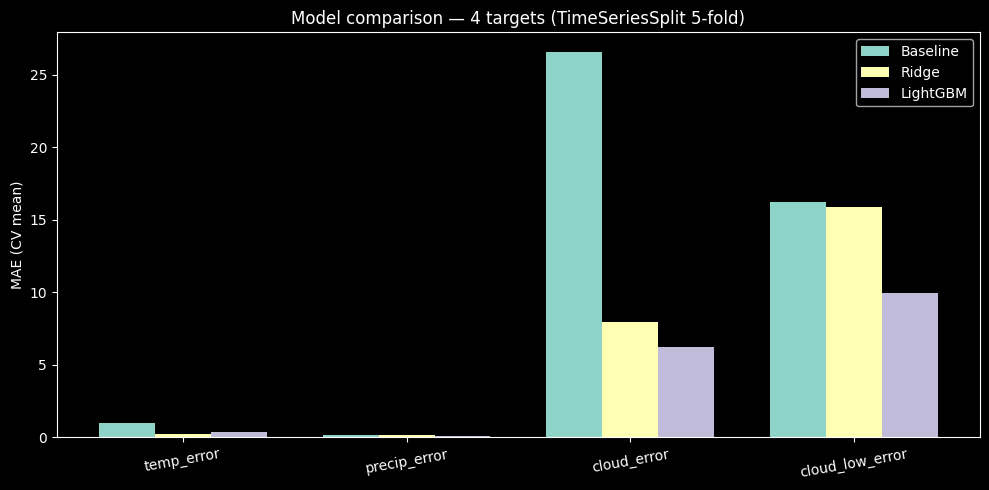

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_df))
w = 0.25
for i, col in enumerate(["Baseline", "Ridge", "LightGBM"]):
    ax.bar(x + (i - 1) * w, model_df[col], w, label=col)
ax.set_xticks(x)
ax.set_xticklabels(model_df.index, rotation=10)
ax.set_ylabel("MAE (CV mean)")
ax.set_title("Model comparison — 4 targets (TimeSeriesSplit 5-fold)")
ax.legend()
plt.tight_layout()
plt.show()

## 4 ターゲット個別学習の結果確認

各ターゲットを独立した LightGBM モデルで学習し、バリデーション MAE を確認する。

In [24]:
N_CV_SPLITS = 5
VALIDATION_RATIO = 0.2

all_results = {}
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    if len(df_t) == 0:
        print(f"SKIP {target}: no rows")
        continue
    feat_cols = get_feat_cols(df_t)
    X_t, y_t = df_t[feat_cols].fillna(0), df_t[target]

    cv_maes = []
    for tr, val in tscv.split(X_t):
        m = lgb.LGBMRegressor(**FINAL_LGBM_PARAMS)
        m.fit(
            X_t.iloc[tr], y_t.iloc[tr],
            eval_set=[(X_t.iloc[val], y_t.iloc[val])],
            callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False), lgb.log_evaluation(period=0)],
        )
        cv_maes.append(mean_absolute_error(y_t.iloc[val], m.predict(X_t.iloc[val])))

    # 最終バリデーション（後方 20%）
    n = len(df_t)
    split_idx = int(n * (1 - VALIDATION_RATIO))
    final_model = lgb.LGBMRegressor(**FINAL_LGBM_PARAMS)
    final_model.fit(
        X_t.iloc[:split_idx], y_t.iloc[:split_idx],
        eval_set=[(X_t.iloc[split_idx:], y_t.iloc[split_idx:])],
        callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False), lgb.log_evaluation(period=0)],
    )
    val_m = metrics(y_t.iloc[split_idx:], final_model.predict(X_t.iloc[split_idx:]))
    baseline_mae = float(y_t.iloc[split_idx:].abs().mean())

    all_results[target] = {
        "unit":         unit,
        "n_rows":       len(df_t),
        "n_features":   len(feat_cols),
        "cv_mae_mean":  np.mean(cv_maes),
        "cv_mae_std":   np.std(cv_maes),
        "val_mae":      val_m["mae"],
        "val_rmse":     val_m["rmse"],
        "val_bias":     val_m["bias"],
        "baseline_mae": baseline_mae,
        "improvement":  (1 - val_m["mae"] / baseline_mae) * 100,
    }
    print(f"[{target}]  cv_mae={np.mean(cv_maes):.4f}  val_mae={val_m['mae']:.4f}  baseline={baseline_mae:.4f}")

[temp_error]  cv_mae=0.3706  val_mae=0.3198  baseline=1.1320
[precip_error]  cv_mae=0.0793  val_mae=0.0752  baseline=0.1502
[cloud_error]  cv_mae=6.2404  val_mae=6.1778  baseline=28.8314
[cloud_low_error]  cv_mae=9.9159  val_mae=10.0203  baseline=17.2794


In [25]:
# 結果サマリー
summary = pd.DataFrame(all_results).T
display(summary[["unit", "n_rows", "cv_mae_mean", "cv_mae_std", "val_mae", "val_rmse", "val_bias", "baseline_mae", "improvement"]].round(4))

,unit,n_rows,cv_mae_mean,cv_mae_std,val_mae,val_rmse,val_bias,baseline_mae,improvement
temp_error,℃,26304,0.3706,0.0362,0.3198,0.4534,-0.0182,1.1320,71.7529
precip_error,mm,26304,0.0793,0.0127,0.0752,0.4366,-0.0052,0.1502,49.9101
cloud_error,%,26304,6.2404,0.9755,6.1778,10.8763,-0.2393,28.8314,78.5727
cloud_low_error,%,26304,9.9159,0.5998,10.0203,17.1256,-0.3261,17.2794,42.0100


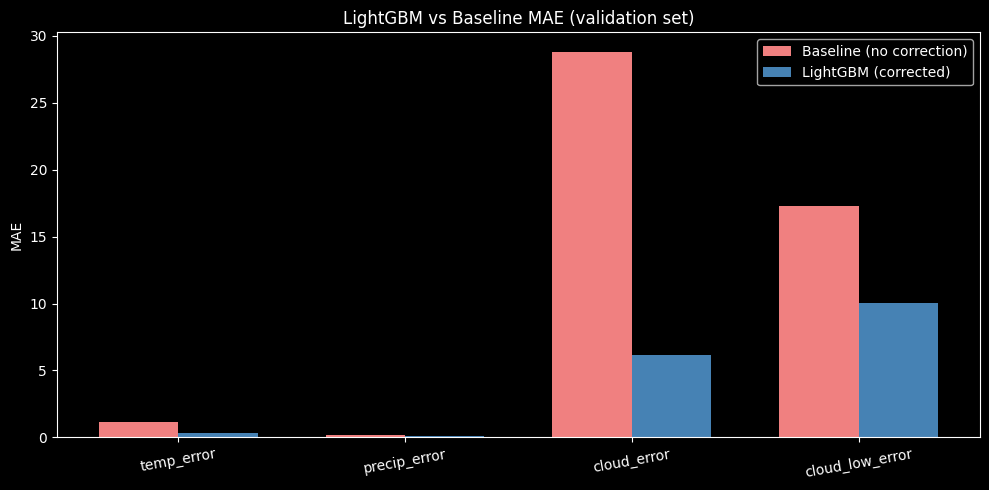

In [26]:
# 各ターゲットのベースライン比較
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_results))
w = 0.35
labels = list(all_results.keys())
baselines = [all_results[t]["baseline_mae"] for t in labels]
val_maes  = [all_results[t]["val_mae"] for t in labels]

ax.bar(x - w/2, baselines, w, label="Baseline (no correction)", color="lightcoral")
ax.bar(x + w/2, val_maes,  w, label="LightGBM (corrected)",     color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel("MAE")
ax.set_title("LightGBM vs Baseline MAE (validation set)")
ax.legend()
plt.tight_layout()
plt.show()

## まとめ: 最終設計決定

| 決定事項 | 選択 | 根拠 |
|-|-|-|
| 分割戦略 | TimeSeriesSplit (n_splits=5) | 時系列データのため未来情報のリークを防ぐ |
| モデル | LightGBM（全ターゲット共通） | 3/4 ターゲットで最良。temp_error は Ridge が優位（0.2555 vs 0.3772）だが実装統一を優先 |
| HP チューニング | Optuna TPESampler (n_trials=50) | 全ターゲット正規化 MAE 平均を最小化。7 パラメータを一括探索 |
| learning_rate | Optuna study により決定（上記セル参照） | TPE ベイズ最適化により速度・精度トレードオフを自動最適化 |
| num_leaves | Optuna study により決定（上記セル参照） | 木の複雑さと汎化誤差のトレードオフを自動最適化 |
| min_child_samples | Optuna study により決定（上記セル参照） | リーフの最小サンプル数（過学習・疎なリーフの抑制） |
| subsample | Optuna study により決定（上記セル参照） | `subsample_freq=1` で Bagging を有効化。lag 特徴量で時系列構造は表現済みのため行サンプリングの影響は限定的 |
| colsample_bytree | Optuna study により決定（上記セル参照） | 列ランダムサブセット化による過学習抑制 |
| reg_alpha / reg_lambda | Optuna study により決定（上記セル参照） | L1 / L2 正則化 |
| early_stopping | 50 rounds | 過学習を自動的に防ぎ本数を最適化 |
| n_estimators | 1000 (上限) | early stopping が実効的に本数を決定 |
| ターゲット | 4 モデル個別 | 各誤差の特性が異なるため独立モデルが有効 |
| 最終評価 | 後方 20% の時系列ホールドアウト | 26,304h × 20% ≈ 5,260h ≈ 7.3 ヶ月分。季節をまたいだ評価に十分な期間 |

→ これらを本番コード `src/apps/train_pipeline.py` に実装する。
→ Optuna 探索後に `study.best_params` を `src/apps/train_pipeline.py` の `LGBM_PARAMS` に反映すること。
→ 次の notebook `05_evaluation_design.ipynb` で品質ゲートを設計する。